# 🎙️ **DCMC-Fusion — K = 2**

This notebook is part of the article **“DCMC-Fusion: Data-Centric and Model-Centric Ensemble Learning for Audio Deepfake Detection”**, by **Dora Ballesteros and Carlos Guerra**.

The project explores ensemble learning for distinguishing natural from synthetic audio by combining probabilities generated by trained deep learning models. The data-centric component evaluates how the composition and number of architectures affect detection performance, while the model-centric component evaluates different machine learning classifiers as fusion mechanisms.


## Experiment: K = 2

- **Input dataset:** contains the inference probabilities generated by **20 trained models**, corresponding to five architectures—ResNet50, DenseNet121, InceptionV3, ResNet34, and VGG16—with four spectral representations per architecture: **Mel, LOG, DWT, and CQT**.

- **Ensemble dataset construction:** **ten datasets** are created from all possible pairs of the five architectures. For **K = 2**, each dataset contains **eight input columns**, combining four spectral probabilities from each of the two selected architectures.

- **Rows and probability values:** each row corresponds to an evaluated audio sample. Probability values range from **0 to 100**, where values closer to 0 indicate natural audio and values closer to 100 indicate synthetic audio.

- **Ground truth:** the **`label`** column identifies the true class of each audio sample: **0 = natural** and **1 = synthetic**. It is used as the target and is not included among the eight input features.

- **Fusion classifiers:** each ensemble dataset is evaluated using **Logistic Regression, Random Forest, XGBoost, and SVM**, resulting in **40 experimental configurations**. The hyperparameters selected in the independent search notebook and the training–test partition remain fixed.

# **1. Dependencies**
Run the installation cell once if the packages are unavailable.

In [1]:
%pip install numpy pandas scikit-learn xgboost ipython --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 43.5 MB/s eta 0:00:00


# **2. Imports**

In [2]:
from pathlib import Path
from itertools import combinations
import json

import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier

# **3. Architecture configuration**

In [3]:
K = 2

ARCHITECTURES = {
    "resnet50": [
        "resnet50_mel", "resnet50_log",
        "resnet50_dwt", "resnet50_cqt"
    ],
    "densenet121": [
        "densenet121_mel", "densenet121_log",
        "densenet121_dwt", "densenet121_cqt"
    ],
    "inception_v3": [
        "inception_v3_mel", "inception_v3_log",
        "inception_v3_dwt", "inception_v3_cqt"
    ],
    "resnet34": [
        "resnet34_mel", "resnet34_log",
        "resnet34_dwt", "resnet34_cqt"
    ],
    "vgg16": [
        "vgg16_mel", "vgg16_log",
        "vgg16_dwt", "vgg16_cqt"
    ]
}

ARCH_ORDER = list(ARCHITECTURES)

FEATURE_COLUMNS = [
    column
    for columns in ARCHITECTURES.values()
    for column in columns
]

CONFIGURATIONS = list(combinations(ARCH_ORDER, K))

# **4. Ensemble dataset preparation**

In [4]:
# Load and validate inference probabilities
CSV_PATH = Path("inference_probabilities.csv")
df = pd.read_csv(CSV_PATH)

required_columns = ["audio", "label"] + FEATURE_COLUMNS
missing_columns = sorted(set(required_columns) - set(df.columns))

if missing_columns:
    raise ValueError(f"Missing columns: {missing_columns}")

values = df[FEATURE_COLUMNS].to_numpy(dtype=float)

if not np.isfinite(values).all() or ((values < 0) | (values > 100)).any():
    raise ValueError("Probabilities must be finite and in [0, 100].")

if set(df["label"].unique()) != {0, 1}:
    raise ValueError("Labels must contain 0 (natural) and 1 (synthetic).")

y = df["label"].to_numpy(dtype=int)

print(f"Audio samples: {len(df)}")

display(
    df["label"]
    .value_counts()
    .sort_index()
    .rename_axis("label")
    .to_frame("samples")
)

display(pd.DataFrame({
    "configuration": [" + ".join(c) for c in CONFIGURATIONS],
    "features": [4 * K] * len(CONFIGURATIONS)
}))

Audio samples: 2484


,samples
label,
0,1242
1,1242


,configuration,features
0,resnet50 + densenet121,8
1,resnet50 + inception_v3,8
2,resnet50 + resnet34,8
3,resnet50 + vgg16,8
4,densenet121 + inception_v3,8
5,densenet121 + resnet34,8
6,densenet121 + vgg16,8
7,inception_v3 + resnet34,8
8,inception_v3 + vgg16,8
9,resnet34 + vgg16,8


# **5. Fixed hyperparameters and shared split**

In [6]:
# Load hyperparameters selected in the independent search notebook
with open("best_hyperparameters.json", encoding="utf-8") as file:
    best_hyperparameters = json.load(file)

with open("experiment_split.json", encoding="utf-8") as file:
    split_configuration = json.load(file)

# Verify dataset identity before applying the saved row indices
if df["audio"].astype(str).tolist() != split_configuration["audio_order"]:
    raise ValueError("Audio samples or their order differ from the saved dataset.")

if y.tolist() != split_configuration["label_order"]:
    raise ValueError("Ground-truth labels differ from the saved dataset.")

if FEATURE_COLUMNS != split_configuration["feature_columns"]:
    raise ValueError("Feature columns differ from the search configuration.")

train_indices = np.array(
    split_configuration["train_indices"], dtype=int
)
test_indices = np.array(
    split_configuration["test_indices"], dtype=int
)

# Verify that the split covers every row exactly once
all_indices = np.concatenate([train_indices, test_indices])

if (
    len(train_indices) == 0
    or len(test_indices) == 0
    or not np.array_equal(np.sort(all_indices), np.arange(len(df)))
):
    raise ValueError("The saved split must partition all rows exactly once.")

RANDOM_STATE = split_configuration["random_state"]
np.random.seed(RANDOM_STATE)

print(f"Training samples: {len(train_indices)}")
print(f"Test samples: {len(test_indices)}")

display(pd.DataFrame({
    "training_samples": pd.Series(y[train_indices]).value_counts(),
    "test_samples": pd.Series(y[test_indices]).value_counts()
}).sort_index().rename_axis("label"))

display(pd.DataFrame([
    {
        "classifier": name,
        "fixed_hyperparameters": json.dumps(parameters, sort_keys=True)
    }
    for name, parameters in best_hyperparameters.items()
]))

Training samples: 1738
Test samples: 746


,training_samples,test_samples
label,,
0,869,373
1,869,373


,classifier,fixed_hyperparameters
0,Logistic Regression,"{""C"": 0.1, ""penalty"": ""l2"", ""solver"": ""saga""}"
1,Random Forest,"{""max_depth"": 5, ""min_samples_split"": 5, ""n_es..."
2,XGBoost,"{""learning_rate"": 0.01, ""max_depth"": 3, ""n_est..."
3,SVM,"{""C"": 0.1, ""gamma"": ""scale"", ""kernel"": ""rbf""}"


# **6. Fusion classifiers**

In [7]:
# The selected hyperparameters remain fixed across all configurations
ML_MODELS = {
    "Logistic Regression": LogisticRegression(
        **best_hyperparameters["Logistic Regression"],
        max_iter=1000,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        **best_hyperparameters["Random Forest"],
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        **best_hyperparameters["XGBoost"],
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        verbosity=0,
        n_jobs=-1
    ),

    "SVM": SVC(
        **best_hyperparameters["SVM"],
        probability=True,
        random_state=RANDOM_STATE
    )
}

# **7. Training and evaluation**

In [8]:
def train_and_evaluate(X_raw, y):
    # Use the same audio samples for every architecture configuration
    X_train = X_raw[train_indices]
    X_test = X_raw[test_indices]
    y_train = y[train_indices]
    y_test = y[test_indices]

    classifier_results = {}

    for name, classifier in ML_MODELS.items():
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", clone(classifier))
        ])

        # Fit preprocessing and classifier using only training data
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        report = classification_report(
            y_test,
            y_pred,
            labels=[0, 1],
            target_names=["natural", "synthetic"],
            output_dict=True,
            zero_division=0
        )

        classifier_results[name] = {
            "y_test": y_test,
            "y_pred": y_pred,
            "accuracy": accuracy_score(y_test, y_pred),
            "report": report,
            "fixed_parameters": best_hyperparameters[name].copy(),
            "trained_pipeline": pipeline
        }

    return classifier_results

# **8. Run the ten configurations**

In [9]:
# Construct each ensemble dataset and train its four fusion classifiers
results = {}

for selected in CONFIGURATIONS:
    configuration_name = " + ".join(selected)

    columns = [
        column
        for architecture in selected
        for column in ARCHITECTURES[architecture]
    ]

    X_raw = df[columns].to_numpy(dtype=float)

    print(
        f"K={K}: {configuration_name} — {len(columns)} features",
        flush=True
    )

    results[configuration_name] = train_and_evaluate(X_raw, y)

print(
    f"Completed: {len(results)} datasets and "
    f"{len(results) * len(ML_MODELS)} classifier configurations."
)

K=2: resnet50 + densenet121 — 8 features
K=2: resnet50 + inception_v3 — 8 features
K=2: resnet50 + resnet34 — 8 features
K=2: resnet50 + vgg16 — 8 features
K=2: densenet121 + inception_v3 — 8 features
K=2: densenet121 + resnet34 — 8 features
K=2: densenet121 + vgg16 — 8 features
K=2: inception_v3 + resnet34 — 8 features
K=2: inception_v3 + vgg16 — 8 features
K=2: resnet34 + vgg16 — 8 features
Completed: 10 datasets and 40 classifier configurations.


# **9. Results: tables and plots**

In [10]:
global_rows = []
class_rows = []
parameter_rows = []

for configuration, classifiers in results.items():
    for classifier, result in classifiers.items():
        base = {
            "K": K,
            "architectures": configuration,
            "classifier": classifier
        }

        macro = result["report"]["macro avg"]

        global_rows.append({
            **base,
            "accuracy": result["accuracy"],
            "precision_macro": macro["precision"],
            "recall_macro": macro["recall"],
            "f1_macro": macro["f1-score"]
        })

        for class_name in ["natural", "synthetic"]:
            metrics = result["report"][class_name]

            class_rows.append({
                **base,
                "class": class_name,
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1-score"],
                "support": int(metrics["support"])
            })

        parameter_rows.append({
            **base,
            "fixed_parameters": json.dumps(
                result["fixed_parameters"],
                sort_keys=True
            )
        })

global_metrics = pd.DataFrame(global_rows)
class_metrics = pd.DataFrame(class_rows)
fixed_parameters = pd.DataFrame(parameter_rows)

# Metrics are reported on a scale from 0 to 1
print("GLOBAL TEST METRICS")
display(global_metrics)

print("PER-CLASS TEST METRICS")
display(class_metrics)

print("FIXED HYPERPARAMETERS")
display(fixed_parameters)

GLOBAL TEST METRICS


,K,architectures,classifier,accuracy,precision_macro,recall_macro,f1_macro
0,2,resnet50 + densenet121,Logistic Regression,0.678284,0.679155,0.678284,0.677893
1,2,resnet50 + densenet121,Random Forest,0.718499,0.753150,0.718499,0.708524
2,2,resnet50 + densenet121,XGBoost,0.715818,0.756144,0.715818,0.704174
3,2,resnet50 + densenet121,SVM,0.690349,0.711918,0.690349,0.682263
4,2,resnet50 + inception_v3,Logistic Regression,0.683646,0.684842,0.683646,0.683134
5,2,resnet50 + inception_v3,Random Forest,0.698391,0.724407,0.698391,0.689389
6,2,resnet50 + inception_v3,XGBoost,0.698391,0.722597,0.698391,0.689963
7,2,resnet50 + inception_v3,SVM,0.684987,0.721245,0.684987,0.671529
8,2,resnet50 + resnet34,Logistic Regression,0.664879,0.665355,0.664879,0.664638
9,2,resnet50 + resnet34,Random Forest,0.706434,0.732551,0.706434,0.697954


PER-CLASS TEST METRICS


,K,architectures,classifier,class,precision,recall,f1,support
0,2,resnet50 + densenet121,Logistic Regression,natural,0.691643,0.643432,0.666667,373
1,2,resnet50 + densenet121,Logistic Regression,synthetic,0.666667,0.713137,0.689119,373
2,2,resnet50 + densenet121,Random Forest,natural,0.846809,0.533512,0.654605,373
3,2,resnet50 + densenet121,Random Forest,synthetic,0.659491,0.903485,0.762443,373
4,2,resnet50 + densenet121,XGBoost,natural,0.857778,0.517426,0.645485,373
...,...,...,...,...,...,...,...,...
75,2,resnet34 + vgg16,Random Forest,synthetic,0.648699,0.935657,0.766191,373
76,2,resnet34 + vgg16,XGBoost,natural,0.913265,0.479893,0.629174,373
77,2,resnet34 + vgg16,XGBoost,synthetic,0.647273,0.954424,0.771398,373
78,2,resnet34 + vgg16,SVM,natural,0.921788,0.442359,0.597826,373


FIXED HYPERPARAMETERS


,K,architectures,classifier,fixed_parameters
0,2,resnet50 + densenet121,Logistic Regression,"{""C"": 0.1, ""penalty"": ""l2"", ""solver"": ""saga""}"
1,2,resnet50 + densenet121,Random Forest,"{""max_depth"": 5, ""min_samples_split"": 5, ""n_es..."
2,2,resnet50 + densenet121,XGBoost,"{""learning_rate"": 0.01, ""max_depth"": 3, ""n_est..."
3,2,resnet50 + densenet121,SVM,"{""C"": 0.1, ""gamma"": ""scale"", ""kernel"": ""rbf""}"
4,2,resnet50 + inception_v3,Logistic Regression,"{""C"": 0.1, ""penalty"": ""l2"", ""solver"": ""saga""}"
5,2,resnet50 + inception_v3,Random Forest,"{""max_depth"": 5, ""min_samples_split"": 5, ""n_es..."
6,2,resnet50 + inception_v3,XGBoost,"{""learning_rate"": 0.01, ""max_depth"": 3, ""n_est..."
7,2,resnet50 + inception_v3,SVM,"{""C"": 0.1, ""gamma"": ""scale"", ""kernel"": ""rbf""}"
8,2,resnet50 + resnet34,Logistic Regression,"{""C"": 0.1, ""penalty"": ""l2"", ""solver"": ""saga""}"
9,2,resnet50 + resnet34,Random Forest,"{""max_depth"": 5, ""min_samples_split"": 5, ""n_es..."


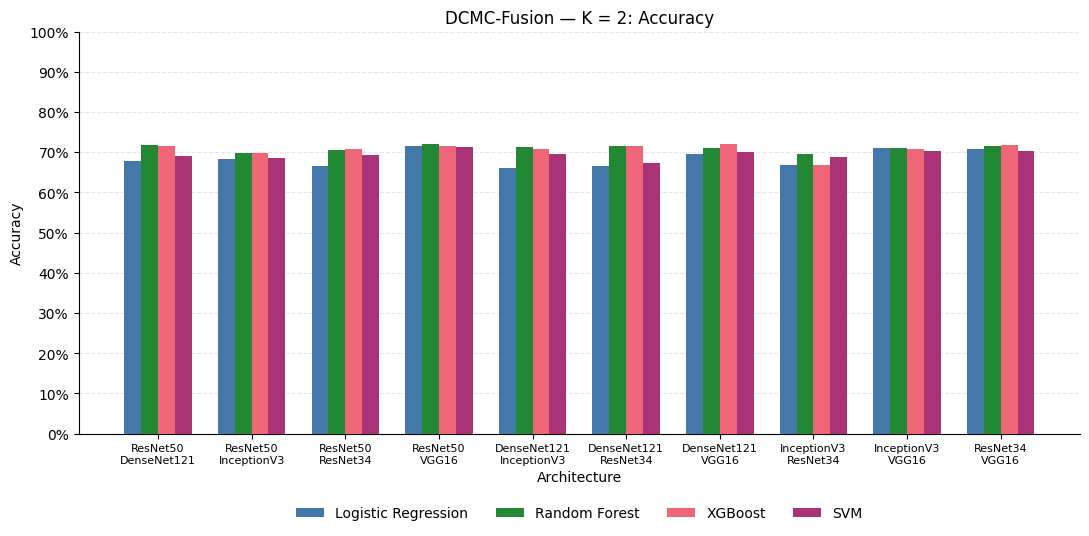

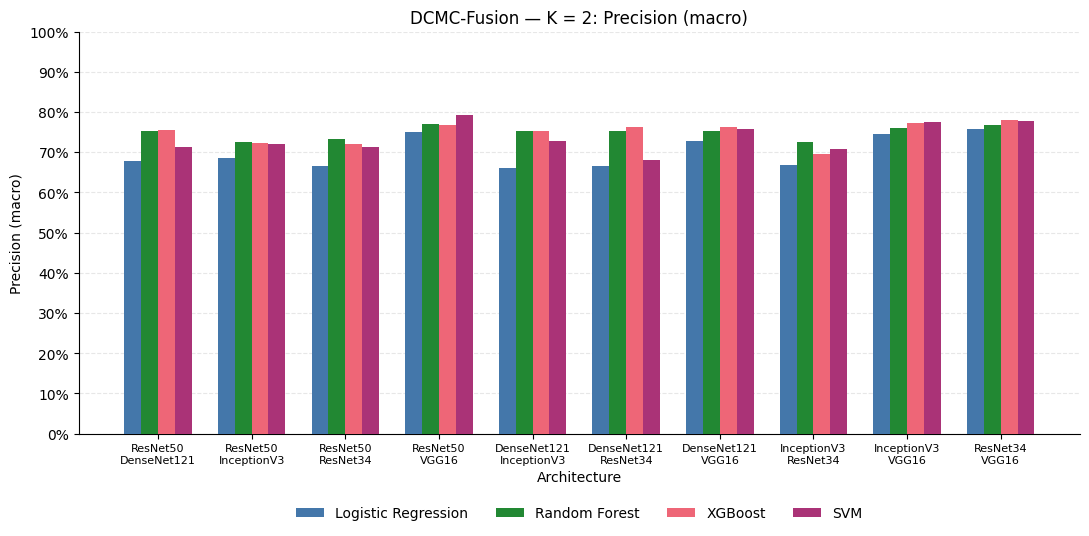

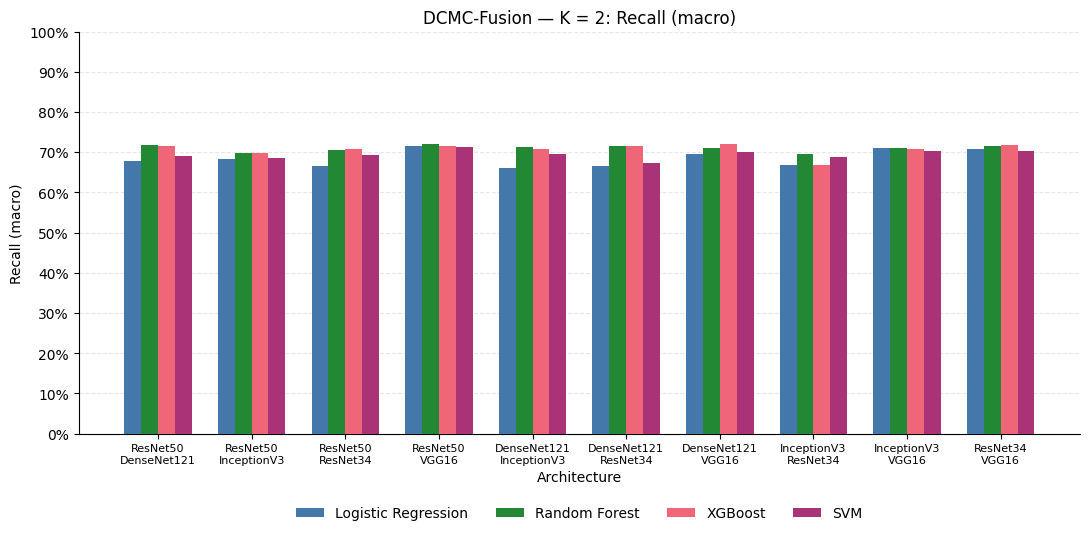

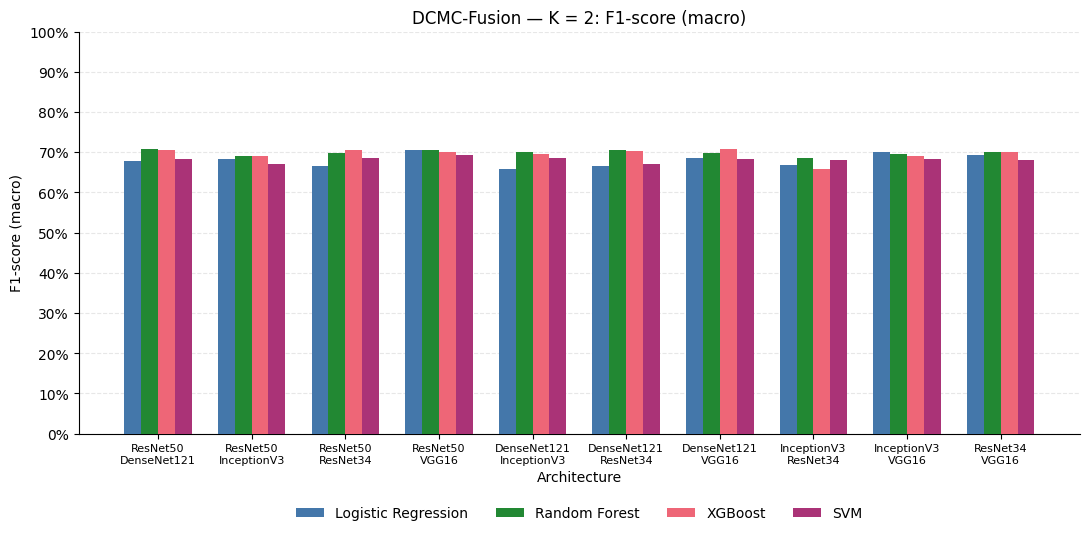

Figures saved to: /content/results/K2/figures


In [13]:
%pip install matplotlib --quiet

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Consistent classifier order and colors across all figures
CLASSIFIER_COLORS = {
    "Logistic Regression": "#4477AA",
    "Random Forest": "#228833",
    "XGBoost": "#EE6677",
    "SVM": "#AA3377"
}

ARCHITECTURE_LABELS = {
    "resnet50": "ResNet50",
    "densenet121": "DenseNet121",
    "inception_v3": "InceptionV3",
    "resnet34": "ResNet34",
    "vgg16": "VGG16"
}

METRICS = {
    "accuracy": "Accuracy",
    "precision_macro": "Precision (macro)",
    "recall_macro": "Recall (macro)",
    "f1_macro": "F1-score (macro)"
}

FIGURE_DIR = Path("results") / f"K{K}" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

configuration_order = [
    " + ".join(selected)
    for selected in CONFIGURATIONS
]

# Display each architecture on a separate line
architecture_labels = [
    "\n".join(ARCHITECTURE_LABELS[arch] for arch in selected)
    for selected in CONFIGURATIONS
]

classifier_order = list(CLASSIFIER_COLORS)
x = np.arange(len(configuration_order))
bar_width = 0.18

for metric, metric_label in METRICS.items():
    metric_table = (
        global_metrics
        .pivot(
            index="architectures",
            columns="classifier",
            values=metric
        )
        .reindex(
            index=configuration_order,
            columns=classifier_order
        )
    )

    if metric_table.isna().any().any():
        raise ValueError(f"Missing results for {metric_label}.")

    fig, ax = plt.subplots(figsize=(11, 5.5))

    for i, classifier in enumerate(classifier_order):
        offset = (i - (len(classifier_order) - 1) / 2) * bar_width

        ax.bar(
            x + offset,
            metric_table[classifier].to_numpy() * 100,
            width=bar_width,
            color=CLASSIFIER_COLORS[classifier],
            label=classifier,
            zorder=3
        )

    ax.set_title(f"DCMC-Fusion — K = {K}: {metric_label}")
    ax.set_xlabel("Architecture")
    ax.set_ylabel(metric_label)

    ax.set_xticks(x)
    ax.set_xticklabels(architecture_labels, fontsize=8)

    ax.set_ylim(0, 100)
    ax.set_yticks(np.arange(0, 101, 10))
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

    ax.grid(axis="y", linestyle="--", alpha=0.3, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.15),
        ncol=4,
        frameon=False
    )

    fig.tight_layout()

    for extension in ["png", "pdf"]:
        fig.savefig(
            FIGURE_DIR / f"K{K}_{metric}.{extension}",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()
    plt.close(fig)

print(f"Figures saved to: {FIGURE_DIR.resolve()}")

# **10. Export results**

In [14]:
OUTPUT_DIR = Path("results") / f"K{K}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

global_metrics.to_csv(
    OUTPUT_DIR / "global_metrics_k2.csv",
    index=False
)

class_metrics.to_csv(
    OUTPUT_DIR / "class_metrics_k2.csv",
    index=False
)

fixed_parameters.to_csv(
    OUTPUT_DIR / "fixed_parameters_k2.csv",
    index=False
)

print(f"Results saved to: {OUTPUT_DIR.resolve()}")

Results saved to: /content/results/K2
